### General advice (delete this cell before submitting for review)

* Update the **Compatibility** line depending on whether the notebook is compatible with the `NCI` and `DEA Sandbox` environments (e.g. "Notebook currently compatible with the `DEA Sandbox` environment only" or "Notebook currently compatible with the `NCI` environment only")
* When adding **Products used**, embed the hyperlink to that specific product on the DEA Explorer using the `[product_name](product url)` syntax.
* When writing in Markdown cells, start each sentence on a **new line**. This makes it easy to see changes through git commits.
* Use Australian English in markdown cells and code comments.
* See the [Knowledge Hub formatting troubleshooting guide](https://github.com/GeoscienceAustralia/dea-notebooks/wiki/Troubleshooting-Knowledge-Hub-formatting) to ensure your formatting will display properly on the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/). Things to be aware of:
    * Sphinx is highly sensitive to bulleted lists:
        * Ensure that there is an empty line between any preceding text and the list
        * Only use the `*` bullet (`-` is not recognised)
        * Sublists must be indented by 4 spaces        
    * Two kinds of formatting cannot be used simultaneously:
        * Hyperlinked code: \[\`code_format\`](hyperlink) fails
        * Bolded code: \*\*\`code_format\`\*\* fails
    * Headers must appear in heirachical order (`#`, `##`, `###`, `####`) and there can only be one title (`#`).
* Use the [PEP8 standard](https://www.python.org/dev/peps/pep-0008/) for code. To make sure all code in the notebook is consistent, you can use the `jupyterlab_code_formatter` tool: select each code cell, then click `Edit` and then one of the `Apply X Formatter` options (`YAPF` or `Black` are recommended). This will reformat the code in the cell to a consistent style.
* For additional guidance, refer to the style conventions and layouts in approved `develop` branch notebooks. Examples include:
    * [How_to_guides/Using_load_ard.ipynb](../How_to_guides/Using_load_ard.ipynb)
    * [Real_world_examples/Coastal_erosion.ipynb](../Real_world_examples/Coastal_erosion.ipynb)
    * [Tools/dea_tools/datahandling.py](../Tools/dea_tools/datahandling.py)
* In the final notebook cell, include a set of relevant tags which are used to build the DEA User Guide's [Tag Index](https://knowledge.dea.ga.gov.au/genindex/). 
Use all lower-case (unless the tag is an acronym), separate words with spaces (unless it is the name of an imported module), and [re-use existing tags](https://github.com/GeoscienceAustralia/dea-notebooks/wiki/List-of-tags).
Ensure the tags cell below is in `Raw` format, rather than `Markdown` or `Code`.

---


# Spatial analysis of wetlands using the Wetlands Insight Tool<img align="right" src="./Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with both the `NCI` and `DEA Sandbox` environments
* **Products used:** 
[ga_ls5t_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls5t_ard_3),
[ga_ls7e_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls7e_ard_3),
[ga_ls8c_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls8c_ard_3),
[ga_ls_wo_3](https://explorer.dea.ga.gov.au/products/ga_ls_wo_3),
[ga_ls_fc_3](https://explorer.dea.ga.gov.au/products/ga_ls_fc_3)
* **Prerequisites:** [DEA_Wetlands_Insight_Tool]()

## Background
An *optional* overview of the scientific, economic or environmental management issue or challenge being addressed by Digital Earth Australia. 
For `Beginners_Guide` or `How_to_guides` notebooks, this may include information about why the particular technique or approach is useful or required. 
If you need to cite a scientific paper or link to a website, use a persistent DOI link if possible and link in-text (e.g. [Dhu et al. 2017](https://doi.org/10.1080/20964471.2017.1402490)).

## Description
A _compulsory_ description of the notebook, including a brief overview of how Digital Earth Australia helps to address the problem set out above.
It can be good to include a run-down of the tools/methods that will be demonstrated in the notebook:

1. First we do this
2. Then we do this
3. Finally we do this

***

## Getting started

Provide any particular instructions that the user might need, e.g. To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

In [28]:
%matplotlib inline

import datacube
import geopandas as gpd
import xarray as xr
import matplotlib.colors as mcolors

import sys
sys.path.insert(1, '../Tools/')
from dea_tools.dask import create_local_dask_cluster
from dea_tools.wetlands import WIT_drill, display_wit_stack_with_df

In [2]:
client = create_local_dask_cluster(return_client=True)

/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46511 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/margaret.harrison@ga.gov.au/proxy/46511/status,
Dashboard: /user/margaret.harrison@ga.gov.au/proxy/46511/status,Workers: 1
Total threads: 2,Total memory: 14.25 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33437,Workers: 1
Dashboard: /user/margaret.harrison@ga.gov.au/proxy/46511/status,Total threads: 2
Started: Just now,Total memory: 14.25 GiB
Comm: tcp://127.0.0.1:41233,Total threads: 2
Dashboard: /user/margaret.harrison@ga.gov.au/proxy/39001/status,Memory: 14.25 GiB
Nanny: tcp://127.0.0.1:33587,


### Connect to the datacube

Connect to the datacube so we can access DEA data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [3]:
dc = datacube.Datacube(app='DEA_Spatial_WIT')

### Analysis parameters

To run this notebook you will need a wetland boudary. You can load a shapefile or geojson, or draw a polygon over your analysis area. 

#### Upload a polygon

You can load in a wetland boundary by uploading your shapefile or GeoJSON into the Sandbox. Alternatively, if your boundary files are hosted online you can use a URL. 

If you are using this notebook for the first time, we recommend using the Hird Swamp example to undestand how the analysis works.

<Axes: >

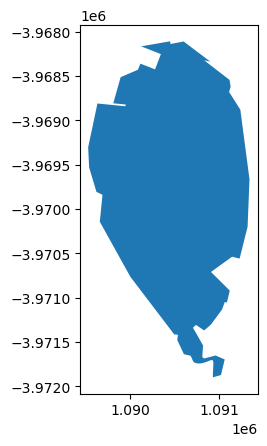

In [4]:
# Example of loading a wetland boundary from file in the Sandbox, Hird Swamp
# Use this boundary if running the notebook for the first time.
wetland_boundary = gpd.read_file("../Supplementary_data/DEA_Wetlands_Insight_Tool/hird.shp")
wetland_boundary.plot()

#### Draw a polygon
You can also create wetland boundary using the widget below. For best performance, the area should be no more than 2,000 square kilometers. 

* Zoom in and out of the map using the `+` and `-` buttons.
* Draw your polygon using the `⬟` polygon tool.
* Click `Finish` when you are happy with your polygon. This will save it as a variable called `wetland_boundary`, and as a GeoJSON in the current directory. 


In [5]:
# %run draw_polygon.py
# draw_polygon_tool()

### Dates for analysis
Select the dates for your analysis in YYYY-MM-DD.

In [6]:
time = ("2014-01-01", "2014-06-01")

## Run the Wetlands Insight Tool using our wetland boundary

The following cell runs the WIT workflow as demonstrated in the [DEA Wetlands Insight Tool product notebook](../DEA_products/DEA_Wetlands_Insight_Tool.ipynb). If you want to know more about the workflow, please refer to that notebook. This will output
* `ds_wit`: an `xarray.Dataset` containing pixel-level time series data for each wetland cover type.
* `df`: a `pandas.DataFrame` summarising the WIT outputs as a time series.

In [7]:
ds_wit, df = WIT_drill(
                        gdf=wetland_boundary,
                        time=time,
                        export_csv='WIT_data.csv',
                        dask_chunks={"time": 1, "x": 2048, "y": 2048},
                        verbose=False,
                        verbose_progress=True,
                    )

Loading Landsat data
Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3 (ignoring SLC-off observations)
    ga_ls5t_ard_3
Applying fmask pixel quality/cloud mask
Returning 18 time steps as a dask array
Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2']


### WIT stacked line plot
We can plot the data as a stacked line plot to understand changes in the cover of bare soil, dry vegetation, green vegetaion, wet vegetation, and open water.

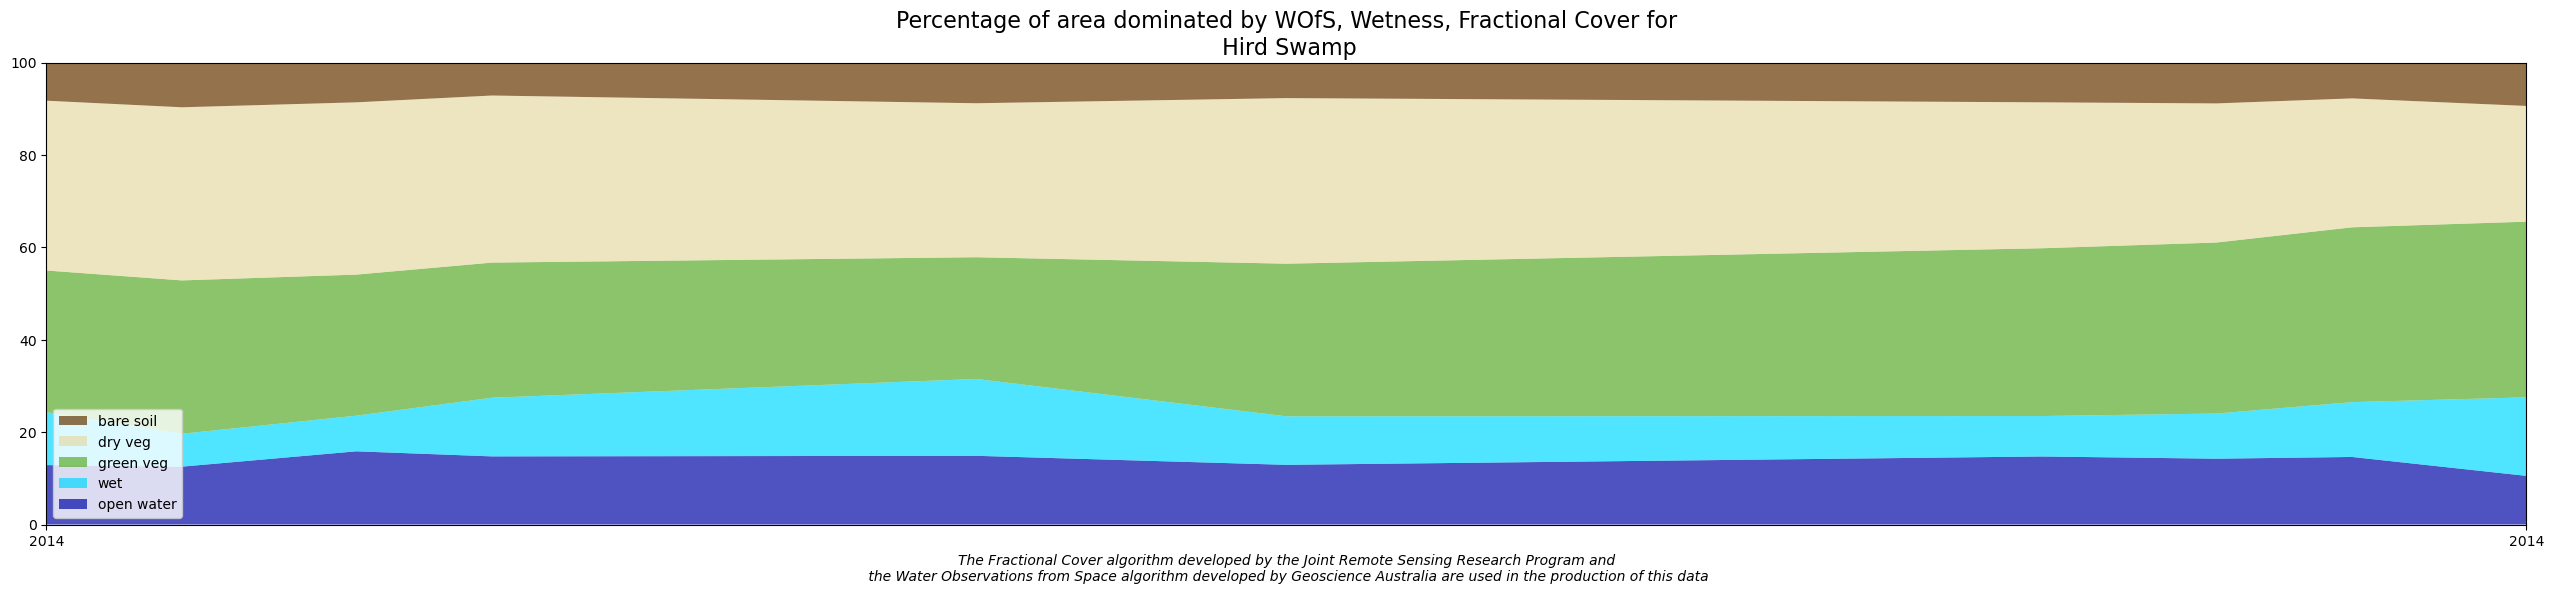

In [10]:
display_wit_stack_with_df(df, 'Hird Swamp', 'stacked_line_plot', x_axis_labels="years")

## Plotting WIT outputs spatially

In [26]:
# Create the 'wetland' variable, fill with the maximum of 'pv', 'npv', and 'bs'
wetland = xr.concat([ds_wit['pv'], ds_wit['npv'], ds_wit['bs']], dim='band').max(dim='band')

# Mask with 'water' where it equals 1
wetland = xr.where(ds_wit['water'] == 1, 1, wetland)

# Mask water with 'wet' where it equals 1
wetland = xr.where(ds_wit['wet'] == 1, 1, wetland)

# Assign the new 'wetland' variable to the dataset
ds_wit['wetland'] = wetland

In [30]:
class_labels = [
    "dry veg",
    "bare soil",
    "green veg", 
    "wet", 
    "water"
]

cmap = mcolors.ListedColormap([
    "#F1E8C9",  # dry vegetation
    "#93724C",  # bare soil
    "#8CC46B",  # green vegetation
    "#6ce6f8",  # wet vegetation
    "#676dca"   # water
])

norm = mcolors.Normalize(vmin=0, vmax=10)

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** September 2021

**Compatible datacube version:** 

In [7]:
print(datacube.__version__)

1.8.19


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->